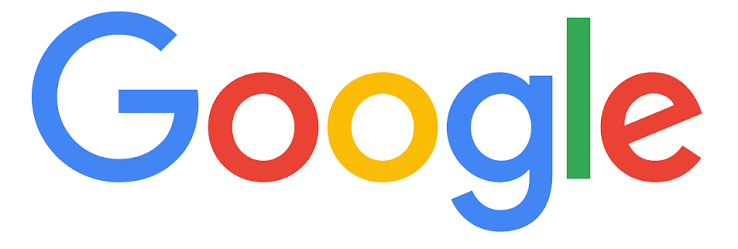

## Scraping Google With Ai Overview without opening Browser

In [3]:
!python --version

Python 3.13.9


In [13]:
!python -c "import requests; print(requests.__version__)"


2.34.2


In [26]:
import IPython
print("IPython Version:", IPython.__version__)

IPython Version: 9.7.0


In [ ]:
!seleniumbase --version 

 
 ___      _          _             ___              
/ __| ___| |___ _ _ (_)_  _ _ __  | _ ) __ _ ______ 
\__ \/ -_) / -_) ' \| | \| | '  \ | _ \/ _` (_-< -_)
|___/\___|_\___|_||_|_|\_,_|_|_|_\|___/\__,_/__|___|
                                                    

C:\Users\Adil\AppData\Local\Programs\Python\Python311\Lib\site-packages\
seleniumbase 4.49.6



## We Have To Extract **NID** Only

In [ ]:
from seleniumbase import Driver

driver = Driver(uc=True)
driver.get("https://www.google.com/search?q=python")

cookies = driver.get_cookies()
for cookie in cookies:
    if cookie['name'] == 'NID':
        # print(cookie['value'])            You      Can    see     Your     NID 
        break

driver.quit()

## Now, NID helps us bypass JavaScript execution.

In [ ]:
import requests
import html as html_lib
from IPython.display import HTML, display

query = "Pakistani Army Chief?"

response = requests.get(
    f"https://www.google.com/search?q={query}",
    headers={
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/150.0.0.0 Safari/537.36"
        )
    },
    cookies={"NID":"533=l_OvhtK-6W6g_akPUzXZuog5GbHqE6w2AH23SaWi0Fc5S42PDBVjVDSb21oneMr5wjrvTMIRg_QcaPHgekJA0o5x3aHc_ELlB5p_F2APrGJ9xAjNh0mGLvuhH4eWH6OR3YhQQY6g5huqY50nSlmoOhQM0tffzWZs_HTuKe5-udN3DzqXUfemileunb-3qv16P9SiwQ"}
)
page_esc = html_lib.escape(response.text, quote=True)

viewer_html = f"""
<iframe
    srcdoc="{page_esc}"
    sandbox="allow-scripts allow-same-origin"
    style="width:100%; height:700px; border:1px solid #30363d;">
</iframe>
"""

display(HTML(viewer_html))

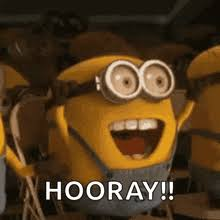,

## Another Search


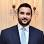
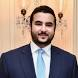
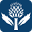
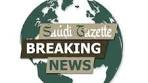

In [27]:
query = "Muhammad Bin Salman"

response = requests.get(
    f"https://www.google.com/search?q={query}",
    headers={
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/150.0.0.0 Safari/537.36"
        )
    },
    cookies={
        cookie["name"]: cookie["value"]  
    }
)
page_esc = html_lib.escape(response.text, quote=True)

viewer_html = f"""
<iframe
    srcdoc="{page_esc}"
    sandbox="allow-scripts allow-same-origin"
    style="width:100%; height:700px; border:1px solid #30363d;">
</iframe>
"""

display(HTML(viewer_html))

## Be careful with your rate limits.

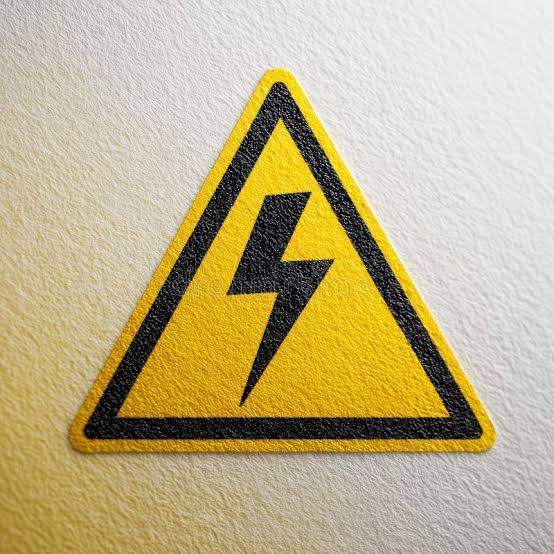

## Notes

If Google temporarily blocks your requests due to a high request rate, your **NID** cookie may become invalid. In that case, you can:

- Generate a new **NID** cookie.
- Rotate your IP address if necessary.

### Best Practices

- Keep a delay of **1.5–2 seconds** between requests.
- Avoid sending requests too quickly.
- Following these practices gives you a **high chance** of avoiding **CAPTCHA** challenges and temporary request blocks.



## Automating SERP Results and AI Overview JSON

This script automates the process of retrieving Google Search (SERP) results and the AI Overview JSON. You can modify it to suit your own requirements.

### How It Works

1. The script extracts the required Google cookies.
2. The **NID** cookie is mandatory, while the remaining cookies are optional. However, the script stores all available cookies for better session consistency.
3. These cookies are saved in a Google session JSON file.
4. The script then uses the stored cookies to fetch search results **without opening a browser**.
5. If the cookies become invalid or Google presents a CAPTCHA/bot verification page, the script automatically generates a new session by collecting fresh cookies and continues the process.


In [34]:
import json
import logging
import time
import re
from collections import OrderedDict
from pathlib import Path
from urllib.parse import quote_plus, urlencode, urlparse, parse_qs

from curl_cffi import requests as curl_requests
from selectolax.parser import HTMLParser

QUERY          = "US Time ?"
COOKIE_FILE    = Path("google_session.json")
IMPERSONATE    = "chrome133a"
CHROME_MAJOR   = 133
HL             = "en"
HEADLESS       = False
RECONNECT_TIME = 1.2
HTTP_TIMEOUT   = 20
MAX_RETRIES    = 3
MIN_HTML_SIZE  = 99_000

CONSENT_SELECTORS = (
    "button#L2AGLb",
    'button[aria-label="Accept all"]',
    'form[action*="consent"] button',
)

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("gfetch")


def chrome_headers(user_agent, referer):
    same = "google.com" in (referer or "")
    return OrderedDict([
        ("sec-ch-ua", f'"Not_A Brand";v="8", "Chromium";v="{CHROME_MAJOR}", "Google Chrome";v="{CHROME_MAJOR}"'),
        ("sec-ch-ua-mobile", "?0"),
        ("sec-ch-ua-platform", '"Windows"'),
        ("upgrade-insecure-requests", "1"),
        ("user-agent", user_agent),
        ("accept", "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7"),
        ("sec-fetch-site", "same-origin" if same else "none"),
        ("sec-fetch-mode", "navigate"),
        ("sec-fetch-user", "?1"),
        ("sec-fetch-dest", "document"),
        ("accept-encoding", "gzip, deflate, br, zstd"),
        ("accept-language", "en-US,en;q=0.9"),
        ("referer", referer or "https://www.google.com/"),
    ])

def bootstrap_cookies_via_browser():
    from seleniumbase import Driver
    log.info("Opening browser for fresh cookies...")
    driver = Driver(uc=True, headless=HEADLESS)
    try:
        driver.uc_open_with_reconnect(
            f"https://www.google.com/search?q=hello&hl={HL}",
            reconnect_time=RECONNECT_TIME)
        for sel in CONSENT_SELECTORS:
            try:
                if driver.is_element_visible(sel):
                    driver.click(sel)
                    break
            except Exception:
                continue
        cookies = {c["name"]: c["value"] for c in driver.get_cookies()}
        ua = driver.execute_script("return navigator.userAgent;")
    finally:
        driver.quit()
        log.info("Browser closed.")
    cookies.setdefault("CONSENT", "YES+")
    session = {"cookies": cookies, "user_agent": ua, "saved_at": int(time.time())}
    COOKIE_FILE.write_text(json.dumps(session, indent=2), encoding="utf-8")
    log.info("Fresh session saved: %s", COOKIE_FILE.resolve())
    return session

def load_session():
    if COOKIE_FILE.exists():
        try:
            s = json.loads(COOKIE_FILE.read_text(encoding="utf-8"))
            if s.get("cookies") and s.get("user_agent"):
                return s
        except Exception:
            log.warning("Saved session corrupt; re-bootstrapping.")
    return bootstrap_cookies_via_browser()

def warmup(session):
    try:
        curl_requests.get("https://www.google.com/", cookies=session["cookies"],
                          headers=chrome_headers(session["user_agent"], ""),
                          impersonate=IMPERSONATE, timeout=HTTP_TIMEOUT)
    except Exception as e:
        log.debug("Warmup skipped: %s", e)

def fetch(query, session, referer="https://www.google.com/"):
    url = f"https://www.google.com/search?q={quote_plus(query)}&hl={HL}"
    log.info("GET %s", url)
    return curl_requests.get(url, cookies=session["cookies"],
                             headers=chrome_headers(session["user_agent"], referer),
                             impersonate=IMPERSONATE, timeout=HTTP_TIMEOUT)


_GARBAGE_MAP = {
    'Â': '', 'â\x80\x93': '-', 'â\x80\x94': '-',
    'â\x80\x99': "'", 'â\x80\x9c': '"', 'â\x80\x9d': '"',
}

def _unescape(s):
    return (s.replace("\\u003d", "=").replace("\\u003D", "=")
             .replace("\\u0026", "&").replace("\\u0026amp;", "&")
             .replace("\\u003f", "?").replace("\\u003F", "?")
             .replace("\\x3d", "=").replace("\\x26", "&")
             .replace("\\/", "/").replace("&amp;", "&"))

def _norm(s):
    if not s: return None
    for bad, good in _GARBAGE_MAP.items():
        s = s.replace(bad, good)
    s = re.sub(r"\s+", " ", s).strip()
    return s or None

def _txt(node, sep=" "):
    if node is None: return None
    return _norm(node.text(strip=True, separator=sep))

def _clean_link(href):
    if not href: return None
    if href.startswith("/url?"):
        try:
            q = parse_qs(urlparse(href).query).get("q")
            if q: href = q[0]
        except Exception:
            return None
    return href if href.startswith("http") else None

def _is_google_host(url):
    try: return "google." in (urlparse(url).netloc or "")
    except Exception: return False

def _ancestors(node, levels=8):
    out, cur = [], node
    for _ in range(levels):
        if cur.parent is None: break
        cur = cur.parent
        out.append(cur)
    return out

_TIME_RE = re.compile(r'(\d{1,2}:\d{2}(?::\d{2})?\s*(?:[AaPp]\.?[Mm]\.?)?)')
_DATE_RE = re.compile(
    r'((?:(?:Mon|Tues|Wednes|Thurs|Fri|Satur|Sun)day,?\s+)?'
    r'(?:'
    r'\d{1,2}\s+(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{4}'
    r'|'
    r'(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},?\s+\d{4}'
    r'))', re.I)
_TZ_RE = re.compile(r'((?:GMT|UTC)\s*[+\-]\s*\d{1,2}(?::\d{2})?)', re.I)

_NOISE_LINE_RE = re.compile(
    r'^(about [\d,]+ results|[\d,]+ results|page \d+|showing results for|'
    r'did you mean|search instead for|results for|sponsored|ad ·|ads ·|'
    r'feedback|learn more|more results|images|maps|news|shopping|videos|books|'
    r'all|tools|safesearch)\b', re.I)
_SECTION_BREAK_RE = re.compile(
    r'^(people also ask|people also search for|related searches|top stories|'
    r'more news|images for|see results about|discussions and forums|'
    r'videos for|web results)\b', re.I)


_SNIPPET_SELECTORS = (".VwiC3b", ".lEBKkf", ".yXK7lf", ".s3v9rd", ".lyLwlc", ".ITZIwc", ".yDYNvb", "[data-sncf]")

def _extract_description(anchor, title, cite_txt):
    ancs = _ancestors(anchor, 8)
    for anc in ancs:
        for sel in _SNIPPET_SELECTORS:
            sn = anc.css_first(sel)
            if sn:
                t = _txt(sn)
                if t and len(t) > 20 and t != title:
                    return t
    for anc in ancs[:5]:
        full = _txt(anc) or ""
        if len(full) - len(title or "") - len(cite_txt or "") > 40:
            d = full
            if title: d = d.replace(title, " ", 1)
            if cite_txt: d = d.replace(cite_txt, " ", 1)
            d = _norm(d)
            if d and len(d) > 25: return d
    return None

def _clean_source_name(anchor, link):
    for anc in _ancestors(anchor, 6):
        s = anc.css_first("span.VuuXrf, .VuuXrf")
        if s:
            t = _txt(s)
            if t:
                return _norm(t.split("›")[0].split("·")[0])
    try:
        host = (urlparse(link).netloc or "").replace("www.", "")
        return host or None
    except Exception:
        return None

def parse_organic(tree):
    results, seen = [], set()
    for h3 in tree.css("h3"):
        title = _txt(h3)
        if not title: continue
        anchor, node = None, h3
        for _ in range(4):
            node = node.parent
            if node is None: break
            if node.tag == "a" and node.attributes.get("href"):
                anchor = node
                break
        if anchor is None: continue
        link = _clean_link(anchor.attributes.get("href"))
        if not link or _is_google_host(link) or link in seen: continue
        seen.add(link)
        cite_txt = None
        for anc in _ancestors(anchor, 5):
            c = anc.css_first("cite")
            if c:
                cite_txt = _txt(c)
                break
        results.append({
            "position":       len(results) + 1,
            "title":          title,
            "link":           link,
            "displayed_link": cite_txt,
            "source":         _clean_source_name(anchor, link),
            "description":    _extract_description(anchor, title, cite_txt),
        })
    return results

def _first_organic_title(tree):
    for h3 in tree.css("h3"):
        title = _txt(h3)
        if not title:
            continue
        node, anchor = h3, None
        for _ in range(4):
            node = node.parent
            if node is None: break
            if node.tag == "a" and node.attributes.get("href"):
                anchor = node; break
        if anchor is None:
            continue
        link = _clean_link(anchor.attributes.get("href"))
        if link and not _is_google_host(link):
            return title
    return None

def parse_knowledge_panel(tree):
    kp = {}
    for sel in ('[data-attrid="title"]', ".qrShPb", ".kp-header h2", ".SPZz6b"):
        v = _txt(tree.css_first(sel))
        if v:
            kp["title"] = v; break
    for sel in ('[data-attrid="subtitle"]', ".wwUB2c", ".YhemCb"):
        v = _txt(tree.css_first(sel))
        if v:
            kp["subtitle"] = v; break
    for sel in ('[data-attrid="description"]', ".kno-rdesc span", ".LrzXr"):
        v = _txt(tree.css_first(sel))
        if v and len(v) > 20:
            kp["description"] = v; break
    attributes = {}
    for el in tree.css("[data-attrid]"):
        attrid = el.attributes.get("data-attrid", "")
        if not attrid.startswith("kc:"): continue
        key = attrid.split(":")[-1].split("/")[-1].replace("_", " ").strip()
        if not key: continue
        val = _txt(el)
        if not val: continue
        val = re.sub(rf"^{re.escape(key)}\s*:?\s*", "", val, flags=re.I).strip()
        val = re.sub(r"^[A-Z][a-z]+:\s+", "", val).strip()
        if val and len(val) < 300:
            attributes.setdefault(key, val)
    if attributes: kp["attributes"] = attributes
    return kp or None


def _parse_featured_snippet(tree):
    _FEATURED_SELECTORS = ('[data-attrid="wa:/description"]', ".hgKElc", ".LGOjhe", ".iAIpHb")
    for sel in _FEATURED_SELECTORS:
        n = tree.css_first(sel)
        if n:
            t = _txt(n)
            if t and len(t) > 10:
                box = {"type": "featured_snippet", "answer": t}
                a = n.parent.css_first("a[href^='http']") if n.parent else None
                if a:
                    link = _clean_link(a.attributes.get("href"))
                    if link and not _is_google_host(link):
                        box["source"] = link
                return box
    return None

def parse_time_answer_box(tree):
    candidates = []
    for sel in ("[role='heading']", ".gsrt", ".vk_bk", ".FzvWSb", ".YwPhnf", ".dDoNo"):
        candidates.extend(tree.css(sel))

    for node in candidates:
        t = _txt(node) or ""
        if len(t) > 40:
            continue
        m = _TIME_RE.search(t)
        if not m or ":" not in m.group(0):
            continue

        box = {"type": "time", "result": _norm(m.group(0))}
        for anc in _ancestors(node, 7):
            atext = _txt(anc) or ""
            if "time in" not in atext.lower():
                continue
            dm = _DATE_RE.search(atext)
            if dm and "date" not in box:
                box["date"] = _norm(dm.group(0))
            descm = re.search(r'(Time in [A-Za-z][A-Za-z .,\'\u00C0-\u024F-]+)', atext)
            if descm and "description" not in box:
                desc = _norm(descm.group(1))
                desc = re.sub(r'\s+(Feedback|Results|Sources|More|Learn more).*$', '', desc, flags=re.I)
                box["description"] = (desc or "").strip(" ,") or None
            tzm = _TZ_RE.search(atext)
            if tzm and "timezone" not in box:
                box["timezone"] = (_norm(tzm.group(1)) or "").replace(" ", "")
            if box.get("date") or box.get("description"):
                break

        if box.get("date") or box.get("description"):
            return box
    return None

def _classify_answer_block(text):
    t = text.lower()
    if re.search(r'°\s*[cf]\b', t) or re.search(r'\b(precipitation|humidity|wind|partly cloudy|mostly|forecast)\b', t):
        return "weather"
    if "time in" in t and _TIME_RE.search(text):
        return "time"
    if re.search(r'\b(usd|eur|gbp|pkr|inr|jpy|aud|cad|aed|sar)\b', t) or "exchange rate" in t:
        return "currency"
    if re.search(r'\d\s*[+\-×x÷*/]\s*\d', t) and re.search(r'[=]\s*[\d.]', t):
        return "calculator"
    if re.search(r'\bvs\.?\b', t) and re.search(r'\d+\s*[-–]\s*\d+', t):
        return "sports"
    return "answer"

def extract_top_answer_block(tree):
    container = (tree.css_first("#rso") or tree.css_first("#search")
                 or tree.css_first("#center_col") or tree.body)
    if container is None:
        return None

    raw = container.text(separator="\n", strip=True) or ""
    if not raw:
        return None

    org_title = _first_organic_title(tree)

    lines = []
    for ln in raw.split("\n"):
        ln = _norm(ln)
        if not ln:
            continue
        if org_title and (ln == org_title or org_title in ln):
            break
        if _SECTION_BREAK_RE.match(ln):
            break
        if _NOISE_LINE_RE.match(ln):
            continue
        lines.append(ln)

    text = _norm(" ".join(lines))
    if not text or len(text) < 8:
        return None
    return {"type": _classify_answer_block(text), "text": text, "lines": lines}

def parse_answer_box(tree):
    return (_parse_featured_snippet(tree)
            or parse_time_answer_box(tree)
            or extract_top_answer_block(tree))

def parse_people_also_ask(tree, query=None):
    qs, seen = [], set()
    ql = (query or "").strip().lower()
    for el in tree.css("[data-q]"):
        q = _norm(el.attributes.get("data-q", ""))
        if not q: continue
        k = q.lower()
        if k == ql or k in seen: continue
        seen.add(k)
        qs.append(q)
    return qs or None

def parse_related_searches(tree, query=None):
    rel, seen = [], set()
    ql = (query or "").strip().lower()
    anchors = []
    for sel in (".AJLUJb", ".k8XOCe", ".s75CSd", ".Q71vJc", ".b2Rnsc"):
        for c in tree.css(sel): anchors.extend(c.css("a"))
    if not anchors: anchors = tree.css('a[href^="/search"]')
    for a in anchors:
        if "/search" not in (a.attributes.get("href", "")): continue
        t = _txt(a)
        if t and 2 < len(t) < 60 and t.lower() != ql and t.lower() not in seen:
            seen.add(t.lower())
            rel.append(t)
    return rel or None

def parse_top_stories(tree, organic_links):
    stories, seen = [], set()
    for a in tree.css("a"):
        link = _clean_link(a.attributes.get("href"))
        if not link or _is_google_host(link) or link in organic_links or link in seen: continue
        head = a.css_first('[role="heading"]')
        if head:
            title = _txt(head)
            if title and len(title) > 15:
                seen.add(link)
                stories.append({"title": title, "link": link})
    return stories or None

def parse_serp_html(raw_html, query=None):
    tree = HTMLParser(raw_html)
    for tag in tree.css("script, style, noscript, template"): tag.decompose()
    def safe(fn, *a):
        try: return fn(*a)
        except Exception: return None
    organic = safe(parse_organic, tree) or []
    organic_links = {r["link"] for r in organic}
    return {
        "answer_box":       safe(parse_answer_box, tree),
        "knowledge_panel":  safe(parse_knowledge_panel, tree),
        "organic_results":  organic or None,
        "people_also_ask":  safe(parse_people_also_ask, tree, query),
        "related_searches": safe(parse_related_searches, tree, query),
        "top_stories":      safe(parse_top_stories, tree, organic_links),
    }


_AI_BOILERPLATE = (
    "An AI Overview is not available for this search",
    "Can't generate an AI overview right now. Try again later.",
    "Can't generate an AI overview right now",
    "Try again later.",
    "AI can make mistakes, so double-check responses",
    "AI responses may include mistakes",
    "Generative AI is experimental",
    "Show more",
    "Show all",
)

_AI_TOKEN_JUNK = re.compile(r'\d+;[\w-]+;[\w-]+|[0-9a-fA-F]+;[\w]+;')

def _strip_ai_boilerplate(s):
    if not s:
        return s
    for phrase in _AI_BOILERPLATE:
        s = re.sub(re.escape(phrase), " ", s, flags=re.I)
    s = _AI_TOKEN_JUNK.sub(" ", s)
    s = re.sub(r"\s+([,.;:!?])", r"\1", s)
    s = re.sub(r"\s{2,}", " ", s).strip()
    return s

def _decode_escapes(s):
    s = re.sub(r'\\u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), s)
    s = re.sub(r'\\x([0-9a-fA-F]{2})', lambda m: chr(int(m.group(1), 16)), s)
    return s.replace('\\/', '/')

def _clean_ai_text(clean_text):
    raw_lines = [l.strip() for l in clean_text.split('\n') if l.strip()]
    final, cur = [], ""
    junk = ['Thinking', 'Searching', 'Thinking a little longer',
            'AI Overview', 'Show more', 'Show all', '·']
    for line in raw_lines:
        if "AI responses may include mistakes" in line or "Learn more" in line:
            break
        if line in junk or re.match(r'^([0-9a-fA-F]+;.*|\[.*\]|].*|.*\]\]\])$', line):
            continue
        cur = (cur + " " + line) if cur else line
        if cur.endswith(('.', '?', '!', '...', '"', '"', ':')):
            cur = re.sub(r'[0-9a-fA-F]+;[a-zA-Z0-9]+;', '', cur)
            final.append(cur.strip())
            cur = ""
    if cur:
        cur = re.sub(r'[0-9a-fA-F]+;[a-zA-Z0-9]+;', '', cur)
        final.append(cur.strip())
    out = " ".join(final).strip()
    out = _strip_ai_boilerplate(out)
    return out or None

def _garbage_fix(s):
    return (s.replace('Â', '').replace('â\x80\x93', '-').replace('â\x80\x94', '-')
             .replace('â\x80\x99', "'").replace('â\x80\x9c', '"').replace('â\x80\x9d', '"'))

def extract_ai_from_html(raw_html):
    tree = HTMLParser(raw_html)

    for tag in tree.css("script, style, svg, img, button, input, g-snackbar, noscript, header, footer"):
        tag.decompose()

    for tag in tree.css("[style*='display:none'], [style*='display: none']"):
        tag.decompose()

    ai_container = tree.css_first("div[data-mcpr], div.YzCcne")
    if ai_container:
        raw_text = ai_container.text(separator='\n', strip=True)
        cleaned = _clean_ai_text(_garbage_fix(raw_text))
        if cleaned and len(cleaned) > 40:
            return cleaned

    full = tree.text(separator='\n', strip=True)
    full_lower = full.lower()

    if "an ai overview is not available" in full_lower or "can't generate an ai overview" in full_lower:
        return None

    lo = full_lower.find("ai overview")
    if lo == -1:
        return None

    hi = full_lower.find("ai responses may include mistakes", lo)
    if hi == -1: hi = full_lower.find("generative ai is experimental", lo)
    if hi == -1: hi = full_lower.find("people also ask", lo)
    if hi == -1: hi = full_lower.find("web results", lo)

    start_idx = lo + 11
    region = full[start_idx:hi] if hi != -1 else full[start_idx:start_idx + 1500]

    txt = _clean_ai_text(_garbage_fix(region))
    return txt if txt and len(txt) > 40 else None

def extract_ai_answer(raw_response):
    decoded = _decode_escapes(raw_response)
    tree = HTMLParser(decoded)
    for tag in tree.css("script, style, svg, img, button, g-snackbar, input"): tag.decompose()
    ct = _garbage_fix(tree.text(separator='\n', strip=True))
    return _clean_ai_text(ct)

def fetch_ai_via_folsrch(raw_html, query, cookies, ua):
    cands = []
    for src in (raw_html, _unescape(raw_html)):
        for m in re.finditer(r'/async/folsrch\?[^"\'<>\s\\]*(?:\\u00[0-9a-fA-F]{2}[^"\'<>\s\\]*)*', src):
            cands.append(m.group(0))

    real = [c for c in set([_unescape(x).rstrip("\\").split('"')[0] for x in cands]) if "mlro=" in c]
    real.sort(key=len, reverse=True)

    url = None
    if real:
        url = "https://www.google.com" + real[0]
    else:
        def ex_tok(k, sh):
            h = _unescape(raw_html)
            m = re.search(rf'[?&]{k}=({sh})', h) or re.search(rf'{k}["\\:=]+({sh})', h)
            return m.group(1) if m else None

        t = {"mlro": ex_tok("mlro", r"[\w-]{40,}"), "mlros": ex_tok("mlros", r"[\w-]{6,30}"),
             "ei": ex_tok("ei", r"[\w-]{16,}"), "sca_esv": ex_tok("sca_esv", r"[0-9a-f]{8,}"),
             "ved": ex_tok("ved", r"[\w-]{12,}"), "vet": ex_tok("vet", r"[\w.-]{12,}")}

        if t["mlro"]:
            qs = {"sca_esv": t["sca_esv"] or "", "yv": "3", "cs": "0", "ei": t["ei"] or "",
                  "async": "_fmt:madl,_id:B2Jtyd,_mado:ed", "q": query, "mlro": t["mlro"],
                  "mlros": t["mlros"] or "", "mgtyp": "90", "snr": "1"}
            if t["vet"]: qs["vet"] = t["vet"]
            if t["ved"]: qs["ved"] = t["ved"]
            url = "https://www.google.com/async/folsrch?" + urlencode({k: v for k, v in qs.items() if v}, safe=":,/")

    if not url: return None

    try:
        referer = f"https://www.google.com/search?q={quote_plus(query)}&hl={HL}"
        hdrs = {
            "accept": "*/*", "accept-encoding": "gzip, deflate, br, zstd",
            "accept-language": "en-US,en;q=0.9", "priority": "u=1, i", "referer": referer,
            "sec-ch-ua": f'"Not_A Brand";v="8", "Chromium";v="{CHROME_MAJOR}", "Google Chrome";v="{CHROME_MAJOR}"',
            "sec-ch-ua-mobile": "?0", "sec-ch-ua-platform": '"Windows"',
            "sec-fetch-dest": "empty", "sec-fetch-mode": "cors", "sec-fetch-site": "same-origin",
            "user-agent": ua, "x-browser-channel": "stable", "x-browser-year": "2026",
        }
        r = curl_requests.get(url, cookies=cookies, headers=hdrs, impersonate=IMPERSONATE, timeout=HTTP_TIMEOUT)
        if r.status_code == 200 and len(r.text) > 300:
            return extract_ai_answer(r.text)
    except Exception:
        pass
    return None

def get_ai_overview(raw_html, query, cookies, ua):
    ai = extract_ai_from_html(raw_html)
    if ai: return ai
    return fetch_ai_via_folsrch(raw_html, query, cookies, ua)


if __name__ == "__main__":
    SESSION = load_session()
    warmup(SESSION)

    GLOBAL_HTML_RESULT = ""
    for attempt in range(1, MAX_RETRIES + 1):
        resp = fetch(QUERY, SESSION)
        html_data = resp.text
        log.info("status %s, size %d chars", resp.status_code, len(html_data))
        if resp.status_code == 200 and len(html_data) > MIN_HTML_SIZE:
            GLOBAL_HTML_RESULT = html_data
            log.info("Success: page fetched.")
            break
        log.warning("Incomplete fetch. Re-bootstrap %d/%d", attempt, MAX_RETRIES)
        if attempt < MAX_RETRIES:
            COOKIE_FILE.unlink(missing_ok=True)
            SESSION = bootstrap_cookies_via_browser()
            warmup(SESSION)

    if not GLOBAL_HTML_RESULT:
        print("❌ HTML data could not be loaded.")
    else:
        serp = parse_serp_html(GLOBAL_HTML_RESULT, QUERY)
        ai_answer = get_ai_overview(GLOBAL_HTML_RESULT, QUERY, SESSION["cookies"], SESSION["user_agent"])

        output = {
            "query":            QUERY,
            "ai_overview":      ai_answer,
            "answer_box":       serp["answer_box"],
            "knowledge_panel":  serp["knowledge_panel"],
            "organic_results":  serp["organic_results"],
            "people_also_ask":  serp["people_also_ask"],
            "related_searches": serp["related_searches"],
            "top_stories":      serp["top_stories"],
        }
        result_json = json.dumps(output, indent=4, ensure_ascii=False)
        print(result_json)

11:47:27 [INFO] Opening browser for fresh cookies...
11:47:43 [INFO] Browser closed.
11:47:43 [INFO] Fresh session saved: E:\github_scraping_project\google_session.json
11:47:44 [INFO] GET https://www.google.com/search?q=US+Time+%3F&hl=en
11:47:45 [INFO] status 200, size 376613 chars
11:47:45 [INFO] Success: page fetched.


{
    "query": "US Time ?",
    "ai_overview": null,
    "answer_box": {
        "type": "time",
        "result": "2:47 am",
        "date": "Friday, 10 July 2026",
        "description": "Time in Washington, DC, USA",
        "timezone": "GMT-4"
    },
    "knowledge_panel": null,
    "organic_results": [
        {
            "position": 1,
            "title": "Current Local Time in the United States",
            "link": "https://www.timeanddate.com/worldclock/usa",
            "displayed_link": "https://www.timeanddate.com › ... › World Clock",
            "source": "Time and Date",
            "description": "Current Local Time in the United States · Los Angeles · PDT · Phoenix · MST. UTC -7. 2:23 pm. Salt Lake City · MDT. UTC -6. 3:23 pm. Read more"
        },
        {
            "position": 2,
            "title": "Time.gov",
            "link": "https://www.time.gov/",
            "displayed_link": "https://www.time.gov",
            "source": "time.gov",
            "descr